In [1]:
# Before making any changes, duplicate this notebook and work on a local version.

# TP 1: Optimization problems and cost functions

**Objective:**
By the end of this lab session, you should be able to:
- Formulate combinatorial optimization problems is python
- Solve some optimization problems using simple methods (such as local, random and exhaustive search)

Especially, we will be interested in implementing problems seen in during the course:
- Max-cut problems
- Ising problems
- Travelling salesman problem
- QUBO problems
- Knapsack problem

Recommended tools and libraries:
- Python (>= 3.10)
- networkx (https://networkx.org/en/)
- sympy (https://www.sympy.org/en/index.html)

Part of the code generated during this session will be reused to create the basis of your optimization library (project that must be finished by 24/03 at midnight CET).


In [ ]:
# Imports used during the lab session
# Networkx is a python package used for the creation and manipulation of graphs
import networkx as nx

# Sympy is a python package used for the creation and manipulation of symbolic expressions
from sympy import *

import itertools

## 1. The Maxcut problem

The max-cut problem is a problem on graphs where the aim is to split the vertices in two subsets such that the number of edges shared by the two sets is maximized.
For a graph $G = (V, E)$ with $V$ the set of vertices and $E$ the set of edges, the cost function to maximize is the following:
$$-\sum_{(v_i, v_j) \in E} s_{v_i} s_{v_j}$$

with $s_v \in \{-1, +1\}$.

In [ ]:
import matplotlib.pyplot as plt
from networkx import nodes

class MaxCutProblem:
    """
    MaxCut cost function: -sum_{(i,j) in E} J_ij * s_i * s_j,  s in {-1, +1}
    Maximizing this = maximizing the number (or weight) of cut edges.
    """

    def __init__(self, graph):
        # TODO 1: store the networkx graph
        self.graph = graph
        self._sympy_expr = None  # cache (TODO 2)

    def to_sympy_expr(self):
        """
        TODO 2: Build and cache the sympy cost expression.
        Each node i gets a symbol s_i. For each edge (i,j) with weight w:
            contribution = -w * s_i * s_j
        """
        if self._sympy_expr is not None:
            return self._sympy_expr

        node_syms = {node: symbols(f"s_{node}") for node in self.graph.nodes()}

        expr = sympify(0)
        for u, v, data in self.graph.edges(data=True):
            weight = data.get("weight", 1)  # TODO 7: weighted support
            expr -= weight * node_syms[u] * node_syms[v]

        self._sympy_expr = expr
        return self._sympy_expr

    def eval(self, solution):
        """
        TODO 3: Evaluate the cost for a given solution dict {node: value in {-1, +1}}.
        """
        expr = self.to_sympy_expr()
        node_syms = {node: symbols(f"s_{node}") for node in self.graph.nodes()}
        subs = {node_syms[node]: val for node, val in solution.items()}
        return float(expr.subs(subs))

    def _maxcut_search_space(self):
        """Toutes les assignations {-1, +1} pour chaque nœud."""
        nodes = list(self.graph.nodes())
        return [
            {node: val for node, val in zip(nodes, combo)}
            for combo in itertools.product([-1, 1], repeat=len(nodes))
        ]
    MaxCutProblem.generate_complete_search_space = _maxcut_search_space

    
    def display_graph(self):
        """TODO 5: Display the graph (nodes, edges, weights if any)."""
        pos = nx.spring_layout(self.graph, seed=42)
        nx.draw(self.graph, pos, with_labels=True,
                node_color="lightblue", node_size=700, font_size=12)
        edge_labels = nx.get_edge_attributes(self.graph, "weight")
        if edge_labels:
            nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels)
        plt.title("MaxCut Graph")
        plt.axis("off")
        plt.show()

    def display_solution(self, solution):
        """
        TODO 6: Display nodes colored by group.
        s = +1 -> red  (group A)
        s = -1 -> blue (group B)
        Cut edges are highlighted in green.
        """
        pos = nx.spring_layout(self.graph, seed=42)

        colors = []
        for node in self.graph.nodes():
            if solution.get(node, 1) == 1:
                colors.append("tomato")
            else:
                colors.append("steelblue")

        edge_colors = []
        for u, v in self.graph.edges():
            if solution.get(u, 1) == solution.get(v, 1):
                edge_colors.append("gray")
            else:
                edge_colors.append("green")

        nx.draw(self.graph, pos, with_labels=True,
                node_color=colors, edge_color=edge_colors,
                node_size=700, font_size=12, width=2)

        edge_labels = nx.get_edge_attributes(self.graph, "weight")
        if edge_labels:
            nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels)

        cost = self.eval(solution)
        plt.title(f"MaxCut Solution | cost = {cost} (red=+1, blue=-1, green=cut edge)")
        plt.axis("off")
        plt.show()


Up to now you should already have tested you code. To test it, create a simple networkx instance (for example, the one that was given as example in class:

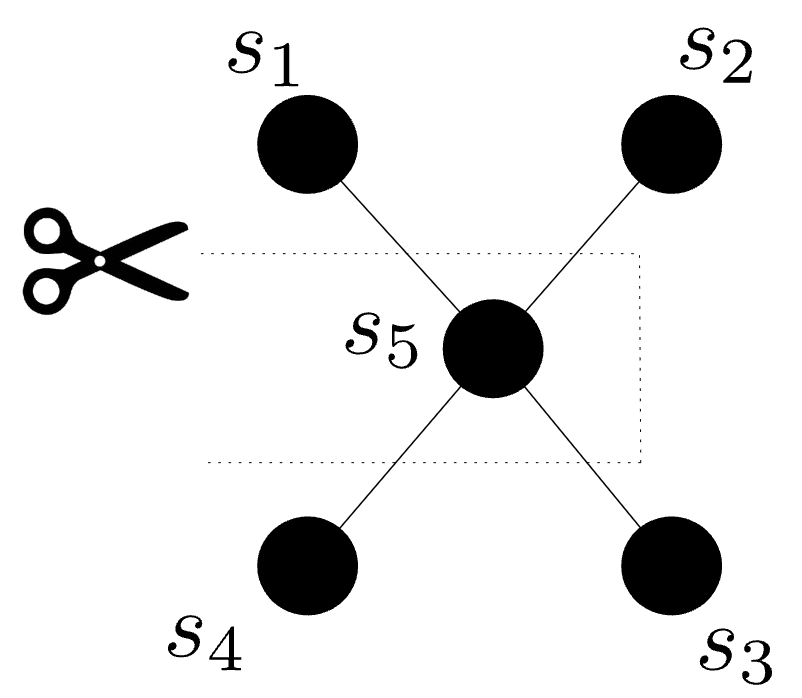




Cost function (sympy): -s_0*s_1 - s_0*s_2 - s_1*s_2 - s_1*s_3 - s_2*s_3
Cost for {0: 1, 1: -1, 2: -1, 3: 1}: 3.0


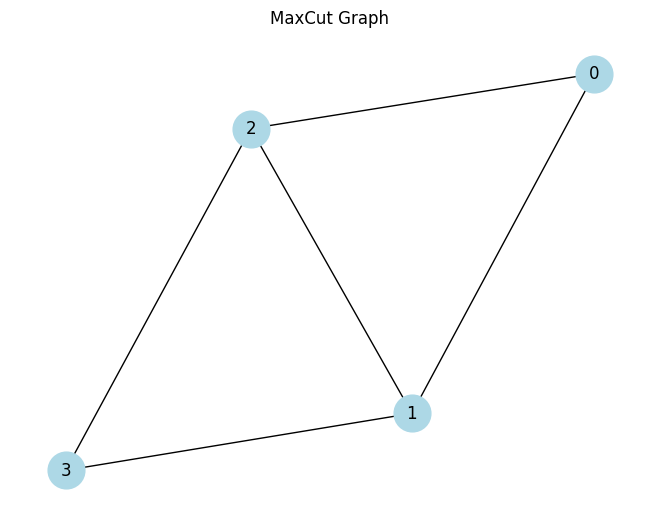

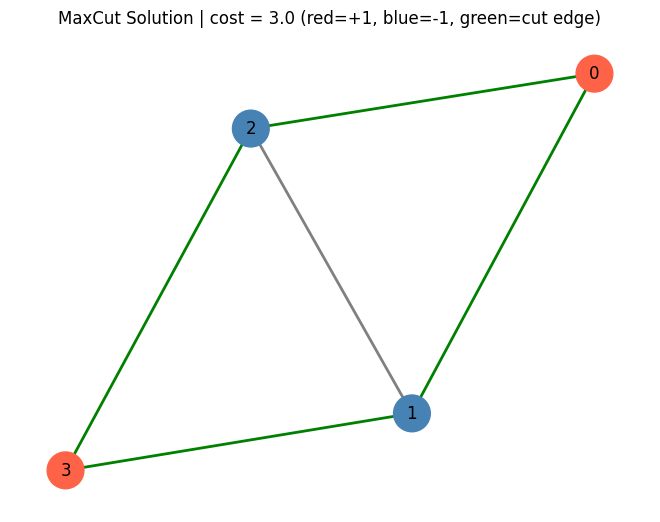

In [4]:
# ----- Test: unweighted graph (example from the course) -----

G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)])

problem = MaxCutProblem(G)

# Show the symbolic cost function
print("Cost function (sympy):", problem.to_sympy_expr())

# Try a solution: group A = {0, 3}, group B = {1, 2}
solution = {0: 1, 1: -1, 2: -1, 3: 1}
print(f"Cost for {solution}: {problem.eval(solution)}")

# Display
problem.display_graph()
problem.display_solution(solution)


Up to now, we only considered the unweighted MaxCut problem. Can you now consider the more general case with a weighted instance. The cost function associated with this kind of instance is:

$$-\sum_{(v_i, v_j) \in E} J_{ij} s_{v_i} s_{v_j}$$

where $J_{ij} \in \mathbb{R}$.

Weighted cost function: -3.0*s_0*s_1 - 1.5*s_0*s_2 - 0.5*s_1*s_2 - 2.0*s_1*s_3 - 4.0*s_2*s_3
Cost for {0: 1, 1: -1, 2: -1, 3: 1}: 10.0


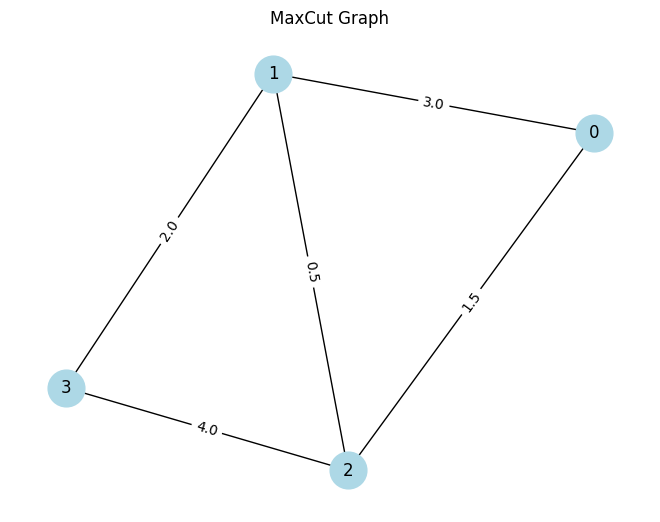

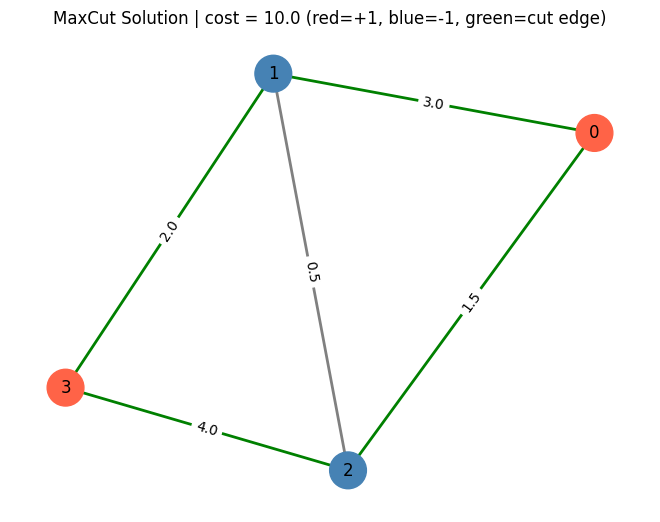

In [5]:
# ----- TODO 7: Weighted MaxCut -----
# The weight J_ij is stored as the "weight" attribute on each edge.
# MaxCutProblem.to_sympy_expr() already handles it via data.get("weight", 1).

G_w = nx.Graph()
G_w.add_weighted_edges_from([
    (0, 1, 3.0),
    (0, 2, 1.5),
    (1, 3, 2.0),
    (2, 3, 4.0),
    (1, 2, 0.5),
])

problem_w = MaxCutProblem(G_w)
print("Weighted cost function:", problem_w.to_sympy_expr())

solution_w = {0: 1, 1: -1, 2: -1, 3: 1}
print(f"Cost for {solution_w}: {problem_w.eval(solution_w)}")

problem_w.display_graph()
problem_w.display_solution(solution_w)


## 2. QUBO (Quadratic Unconstrained Binary optimization) problem

A QUBO problem is represented by either:
- a triangular upper matrix
- a symmetric matrix

The QUBO problem is formally stated as:
$$\min f(Q) = \sum_{i=1}^n\sum_{j=1}^n Q_{i, j} x_i x_j$$

where $Q$ is the matrix and $x_i \in \{0, 1\}$.

In [ ]:
import numpy as np
from scipy.linalg import issymmetric

class QuboProblem:
    """
    QUBO: minimize f(x) = sum_i sum_j Q_ij * x_i * x_j,  x in {0, 1}
    Q must be upper triangular OR symmetric.
    """

    def __init__(self, matrix):
        # Convert to numpy array if needed
        Q = np.array(matrix, dtype=float)

        # Check: upper triangular or symmetric
        is_upper_tri = np.allclose(Q, np.triu(Q))
        is_sym = np.allclose(Q, Q.T)

        if not is_upper_tri and not is_sym:
            raise ValueError("Q must be upper triangular or symmetric.")

        # Work internally with upper triangular form
        if is_sym and not is_upper_tri:
            Q = np.triu(Q)

        self.Q = Q
        self.n = Q.shape[0]
        self._sympy_expr = None

    def to_sympy_expr(self):
        """
        TODO 9: Build the sympy expression sum_i sum_j Q_ij * x_i * x_j
        Only upper triangle is stored, so we iterate i <= j.
        """
        if self._sympy_expr is not None:
            return self._sympy_expr

        x = [symbols(f"x_{i}") for i in range(self.n)]

        expr = sympify(0)
        for i in range(self.n):
            for j in range(i, self.n):
                if self.Q[i, j] != 0:
                    expr += self.Q[i, j] * x[i] * x[j]

        self._sympy_expr = expr
        return self._sympy_expr

    def eval(self, solution):
        """
        TODO 10: Evaluate cost via vector-matrix multiplication: x^T Q x
        solution: dict {i -> value} or list, with values in {0, 1}
        """
        if isinstance(solution, dict):
            x = np.array([solution[i] for i in range(self.n)], dtype=float)
        else:
            x = np.array(solution, dtype=float)

        return float(x @ self.Q @ x)
    
    def _qubo_search_space(self):
        """Toutes les assignations {0, 1} pour chaque variable."""
        return [
            {i: val for i, val in enumerate(combo)}
            for combo in itertools.product([0, 1], repeat=self.n)
        ]
    QuboProblem.generate_complete_search_space = _qubo_search_space



In [7]:
# TODO 11: Toy example to verify QuboProblem

# Simple 3x3 upper triangular QUBO matrix
Q = [
    [1, -2,  0],
    [0,  3, -1],
    [0,  0,  2],
]

qubo = QuboProblem(Q)
print("Sympy expression:", qubo.to_sympy_expr())

# Test a solution: x0=1, x1=0, x2=1
sol = {0: 1, 1: 0, 2: 1}
print(f"Cost for {sol}: {qubo.eval(sol)}")
# Expected: Q00*1 + Q02*1*1 + Q22*1 = 1 + 0 + 2 = 3

# Also test with a symmetric matrix
Q_sym = [
    [2,  1, 0],
    [1,  3, 2],
    [0,  2, 1],
]
qubo_sym = QuboProblem(Q_sym)
print("\nSymmetric matrix -> stored as upper tri:")
print(qubo_sym.Q)
print("Sympy expression:", qubo_sym.to_sympy_expr())


Sympy expression: 1.0*x_0**2 - 2.0*x_0*x_1 + 3.0*x_1**2 - 1.0*x_1*x_2 + 2.0*x_2**2
Cost for {0: 1, 1: 0, 2: 1}: 3.0

Symmetric matrix -> stored as upper tri:
[[2. 1. 0.]
 [0. 3. 2.]
 [0. 0. 1.]]
Sympy expression: 2.0*x_0**2 + 1.0*x_0*x_1 + 3.0*x_1**2 + 2.0*x_1*x_2 + 1.0*x_2**2


## 3. Ising problems

An Ising problem is represented by a cost function on $n$ variables:

$$\min C_{Ising} = \sum_{i=1}^n w_i s_i + \sum_{i<j} w_{i, j} s_i s_j$$

where $w_i$ and $w_{i, j}$ are the weights of the problem.

In [ ]:
from ast import expr

from matplotlib.pylab import indices
import networkx as nx
from sympy import symbols, sympify, expand

class IsingProblem:
    """
    Ising problem: minimize H = sum_{i<j} J_ij * s_i * s_j + sum_i h_i * s_i
    s_i in {-1, +1}

    Accepts either:
      - A sympy expression string (e.g. "2*s_0*s_1 - s_0")
      - A networkx Graph where edge attribute 'weight' = J_ij
        and optional node attribute 'h' = h_i (local field)
    """

    def __init__(self, input_data):
        # TODO 12
        self._sympy_expr = None
        self._input = input_data

        if isinstance(input_data, str):
            self._sympy_expr = sympify(input_data)
        elif not isinstance(input_data, nx.Graph):
            raise ValueError("Input must be a sympy expression string or a networkx Graph.")

    def to_sympy_expr(self):
        """TODO 12: Build and cache the sympy cost expression."""
        if self._sympy_expr is not None:
            return self._sympy_expr

        graph = self._input
        node_syms = {node: symbols(f"s_{node}") for node in sorted(graph.nodes())}

        expr = sympify(0)
        for u, v, data in graph.edges(data=True):
            weight = data.get("weight", 1)
            expr += weight * node_syms[u] * node_syms[v]
        for node, data in graph.nodes(data=True):
            h = data.get("h", 0)
            if h != 0:
                expr += h * node_syms[node]

        self._sympy_expr = expr
        return self._sympy_expr

    def get_cost(self, solution):
        """
        TODO 13: Evaluate the Ising cost for a given solution.
        solution: dict {node_index -> value in {-1, +1}}
        """
        expr = self.to_sympy_expr()
        subs = {}
        for sym in expr.free_symbols:
            parts = str(sym).split('_')
            if len(parts) >= 2:
                try:
                    idx = int(parts[-1])
                    if idx in solution:
                        subs[sym] = solution[idx]
                except ValueError:
                    pass
        return float(expr.subs(subs))
    
    def _ising_search_space(self):
        """Toutes les assignations {-1, +1} pour chaque variable de l'expression."""
        expr = self.to_sympy_expr()
        syms = sorted(expr.free_symbols, key=lambda s: int(str(s).split('_')[-1]))
        indices = [int(str(s).split('_')[-1]) for s in syms]
        return [
            {idx: val for idx, val in zip(indices, combo)}
            for combo in itertools.product([-1, 1], repeat=len(indices))
        ]
    IsingProblem.generate_complete_search_space = _ising_search_space
    IsingProblem.eval = IsingProblem.get_cost   # alias pour les fonctions de recherche

    eval = get_cost 

# TODO 14: Toy example ---------------------------------------------------

# (a) From a sympy expression string
ising_str = IsingProblem("2*s_0*s_1 - s_0 + s_1")
print("From string:", ising_str.to_sympy_expr())
sol = {0: 1, 1: -1}
# Expected: 2*(1)*(-1) - 1 + (-1) = -4
print(f"Cost for {sol}: {ising_str.get_cost(sol)}")

# (b) From a networkx graph
G_ising = nx.Graph()
G_ising.add_edge(0, 1, weight=2)
G_ising.nodes[0]['h'] = -1
G_ising.nodes[1]['h'] =  1
ising_graph = IsingProblem(G_ising)
print("From graph:", ising_graph.to_sympy_expr())
print(f"Cost for {sol}: {ising_graph.get_cost(sol)}")

From string: 2*s_0*s_1 - s_0 + s_1
Cost for {0: 1, 1: -1}: -4.0
From graph: 2*s_0*s_1 - s_0 + s_1
Cost for {0: 1, 1: -1}: -4.0


In [9]:
import numpy as np
from sympy import symbols, sympify, expand

def qubo_to_ising(qubo_problem):
    """
    TODO 15: Convert a QuboProblem to an IsingProblem using x_i = (1 + s_i) / 2.
    J_ij = Q_ij / 4          (i < j)
    h_i  = Q_ii/2 + (1/4) * sum_{j != i} Q_sym[i, j]
    """
    Q = qubo_problem.Q  # upper triangular
    n = qubo_problem.n

    # Full symmetric matrix for easy row-sum computation
    Q_sym = Q + Q.T - np.diag(np.diag(Q))

    # Coupling matrix J (off-diagonal upper triangle)
    J = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            J[i, j] = Q[i, j] / 4

    # Local fields h
    h = np.zeros(n)
    for i in range(n):
        off_diag_sum = np.sum(Q_sym[i, :]) - Q_sym[i, i]
        h[i] = Q[i, i] / 2 + off_diag_sum / 4

    # Build sympy expression
    s = [symbols(f"s_{i}") for i in range(n)]
    expr = sympify(0)
    for i in range(n):
        for j in range(i + 1, n):
            if J[i, j] != 0:
                expr += J[i, j] * s[i] * s[j]
        if h[i] != 0:
            expr += h[i] * s[i]

    return IsingProblem(str(expr))


def ising_to_qubo(ising_problem):
    """
    TODO 16: Convert an IsingProblem to a QuboProblem using s_i = 2*x_i - 1.
    Q_ij = 4 * J_ij          (i < j)
    Q_ii = 2*h_i - 2 * sum_{j != i} J_ij
    """
    expr = expand(ising_problem.to_sympy_expr())

    syms = sorted(expr.free_symbols, key=lambda sym: int(str(sym).split('_')[1]))
    if not syms:
        return QuboProblem(np.zeros((1, 1)))

    n = int(str(syms[-1]).split('_')[1]) + 1
    s = [symbols(f"s_{i}") for i in range(n)]

    # Extract coupling matrix J (symmetric)
    J = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            c = float(expr.coeff(s[i] * s[j]))
            J[i, j] = c
            J[j, i] = c

    # Extract local fields h
    h = np.zeros(n)
    for i in range(n):
        expr_i = expr.subs([(s[j], 0) for j in range(n) if j != i])
        h[i] = float(expr_i.coeff(s[i]))

    # Build QUBO matrix (upper triangular)
    Q = np.zeros((n, n))
    for i in range(n):
        Q[i, i] = 2 * h[i] - 2 * np.sum(J[i, :])
        for j in range(i + 1, n):
            Q[i, j] = 4 * J[i, j]

    return QuboProblem(Q)


# Quick round-trip test
print("=== QUBO -> Ising ===")
Q_mat = [[1, -2, 0],
         [0,  3, -1],
         [0,  0,  2]]
qubo = QuboProblem(Q_mat)
ising = qubo_to_ising(qubo)
print("QUBO expr :", qubo.to_sympy_expr())
print("Ising expr:", ising.to_sympy_expr())

print("=== Ising -> QUBO ===")
qubo2 = ising_to_qubo(ising)
print("Recovered QUBO expr:", qubo2.to_sympy_expr())
print("QUBO Q matrix", qubo2.Q)

=== QUBO -> Ising ===
QUBO expr : 1.0*x_0**2 - 2.0*x_0*x_1 + 3.0*x_1**2 - 1.0*x_1*x_2 + 2.0*x_2**2
Ising expr: -0.5*s_0*s_1 - 0.25*s_1*s_2 + 0.75*s_1 + 0.75*s_2
=== Ising -> QUBO ===
Recovered QUBO expr: 1.0*x_0**2 - 2.0*x_0*x_1 + 3.0*x_1**2 - 1.0*x_1*x_2 + 2.0*x_2**2
QUBO Q matrix [[ 1. -2.  0.]
 [ 0.  3. -1.]
 [ 0.  0.  2.]]


## 4. Knapsack problem

Given a set of items, each with a weight and a value, determine which items to include in the collection so that the total weight is less than or equal to a given limit and the total value is as large as possible.

Search space:
$$\mathcal{X}=\{0, 1\}^n$$

Objective function:
$$\max \sum_i x_i p_i , x_i \in \{0, 1\}$$

Constraints:
$$\text{s.t. }\sum_i w_i x_i < W$$

with $p_i$ the price of the object and $w_i$ its weight


In [ ]:
# TODO 17: Create a new class KnapsackProblem which can be used to create the Knapsack problem.
#         Add a method is_feasible checking that a solution is feasible before evaluating its cost.
#         Add a method eval which returns the solution to a given instance
# Create a toy instance and check that your code is working as expected.

class KnapsackProblem:
    """
    Knapsack problem:
        maximize  sum_i x_i * p_i
        subject to sum_i x_i * w_i <= W
        x_i in {0, 1}

    Parameters
    ----------
    weights : list of floats/ints
        w_i : weight of item i
    values : list of floats/ints
        p_i : value (profit) of item i
    capacity : float/int
        W : maximum weight capacity
    """

    def __init__(self, weights, values, capacity):
        if len(weights) != len(values):
            raise ValueError("weights and values must have the same length.")
        self.weights = list(weights)
        self.values = list(values)
        self.capacity = capacity
        self.n = len(weights)

    def is_feasible(self, solution):
        """
        Check whether a binary solution satisfies the weight constraint.

        Parameters
        ----------
        solution : list or dict
            Binary vector x in {0,1}^n.
            - list  : x[i] is the value for item i
            - dict  : {i: value} mapping

        Returns
        -------
        bool : True if sum_i x_i * w_i <= W
        """
        if isinstance(solution, dict):
            x = [solution[i] for i in range(self.n)]
        else:
            x = list(solution)

        total_weight = sum(x[i] * self.weights[i] for i in range(self.n))
        return total_weight <= self.capacity

    def eval(self, solution):
        """
        Evaluate the objective value of a solution (total value of selected items).
        Returns -inf if the solution is not feasible.

        Parameters
        ----------
        solution : list or dict
            Binary vector x in {0,1}^n.

        Returns
        -------
        float : total value if feasible, else float("-inf")
        """
        if not self.is_feasible(solution):
            return float("-inf")

        if isinstance(solution, dict):
            x = [solution[i] for i in range(self.n)]
        else:
            x = list(solution)

        return sum(x[i] * self.values[i] for i in range(self.n))

    def _knapsack_search_space(self):
        """Toutes les combinaisons binaires {0, 1}^n."""
        return [list(combo) for combo in itertools.product([0, 1], repeat=self.n)]
    KnapsackProblem.generate_complete_search_space = _knapsack_search_space


# ----- Toy example -----
# Items: (weight, value)
#   Item 0: weight=2, value=6
#   Item 1: weight=2, value=10
#   Item 2: weight=3, value=12
#   Capacity W=5
#
# Optimal: take items 1 and 2 -> weight=5, value=22

weights  = [2, 2, 3]
values   = [6, 10, 12]
capacity = 5

knapsack = KnapsackProblem(weights, values, capacity)

# Test is_feasible
sol_feasible   = [0, 1, 1]  # weight=5 <= 5 => feasible
sol_infeasible = [1, 1, 1]  # weight=7 >  5 => infeasible

print("Feasible   [0,1,1]:", knapsack.is_feasible(sol_feasible))   # True
print("Infeasible [1,1,1]:", knapsack.is_feasible(sol_infeasible))  # False

# Test eval
print("Value [0,1,1]:", knapsack.eval(sol_feasible))   # 22
print("Value [1,1,1]:", knapsack.eval(sol_infeasible))  # -inf

# Exhaustive search over all 2^n solutions
best_sol   = None
best_value = float("-inf")

for mask in range(2 ** knapsack.n):
    x = [(mask >> i) & 1 for i in range(knapsack.n)]
    v = knapsack.eval(x)
    if v > best_value:
        best_value = v
        best_sol   = x

print()
print("Best solution (exhaustive):", best_sol)
print("Best value               :", best_value)
print("Total weight             :", sum(best_sol[i]*weights[i] for i in range(knapsack.n)))


Feasible   [0,1,1]: True
Infeasible [1,1,1]: False
Value [0,1,1]: 22
Value [1,1,1]: -inf

Best solution (exhaustive): [0, 1, 1]
Best value               : 22
Total weight             : 5


## 5. Travelling Salesman Problem (TSP)

Given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city exactly once and returns to the origin city?

Search space (set of all the permutations):
$$\mathcal{X} = S_n$$

$$S_n = \{[\text{city}_1, \text{city}_2, \text{city}_3, ... \text{city}_n], [\text{city}_2, \text{city}_1, \text{city}_3, ... \text{city}_n] ...\}$$


In [11]:
# TODO 18: Create a new class TspProblem which can be used to create an instance of the TSP problem.
#         Add a method eval which returns the solution to a given instance
#         Add a method display_solution(solution) which displays the solution to the TSP problem
# Create a toy instance and check that your code is working as expected.

Naive route distance : 14.7229


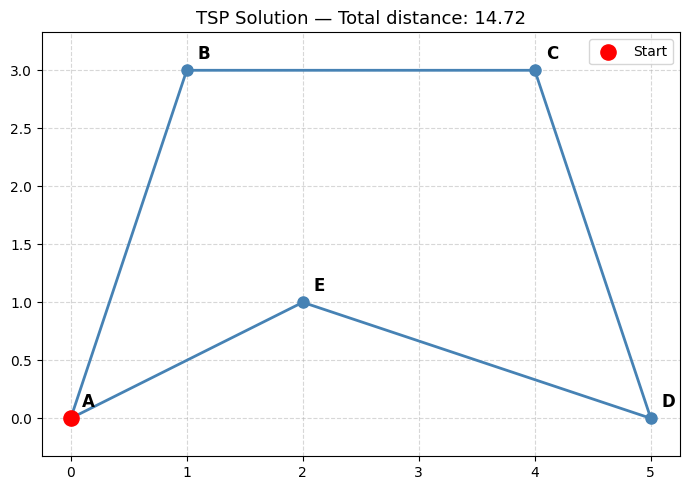

Route  : A → B → C → D → E → A
Distance: 14.7229


In [ ]:
# TODO 18: TspProblem class

import numpy as np
import matplotlib.pyplot as plt
import itertools

class TspProblem:
    """
    Travelling Salesman Problem instance.
    
    Parameters:
        cities (dict): {city_name: (x, y)} coordinates
        distances (dict, optional): precomputed {(city_i, city_j): distance}
                                    If None, Euclidean distances are computed from coords.
    """
    def __init__(self, cities: dict, distances: dict = None):
        self.cities = cities                          # {name: (x, y)}
        self.city_names = list(cities.keys())
        
        # Build distance matrix
        if distances is not None:
            self.distances = distances
        else:
            self.distances = {}
            for a, b in itertools.combinations(self.city_names, 2):
                xa, ya = cities[a]
                xb, yb = cities[b]
                d = np.sqrt((xa - xb)**2 + (ya - yb)**2)
                self.distances[(a, b)] = d
                self.distances[(b, a)] = d

    def eval(self, solution: list) -> float:
        """
        Evaluate the total distance of a given route (solution).
        
        Parameters:
            solution (list): ordered list of city names, e.g. ['A', 'B', 'C']
                             The route automatically returns to the starting city.
        Returns:
            float: total route distance (lower is better → minimization problem)
        """
        total = 0.0
        n = len(solution)
        for i in range(n):
            city_from = solution[i]
            city_to   = solution[(i + 1) % n]   # wrap around to origin
            total += self.distances[(city_from, city_to)]
        return total

    def display_solution(self, solution: list):
        """
        Display the solution route on a 2D plot and print total distance.
        
        Parameters:
            solution (list): ordered list of city names
        """
        total_dist = self.eval(solution)
        route = solution + [solution[0]]          # close the loop for display

        xs = [self.cities[c][0] for c in route]
        ys = [self.cities[c][1] for c in route]

        plt.figure(figsize=(7, 5))
        plt.plot(xs, ys, '-o', color='steelblue', linewidth=2, markersize=8)

        # Annotate city names
        for city, (x, y) in self.cities.items():
            plt.annotate(city, (x, y), textcoords="offset points",
                         xytext=(8, 8), fontsize=12, fontweight='bold')

        # Mark starting city
        start = solution[0]
        plt.scatter(*self.cities[start], color='red', zorder=5, s=120, label='Start')

        plt.title(f"TSP Solution — Total distance: {total_dist:.2f}", fontsize=13)
        plt.legend()
        plt.axis('equal')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        print(f"Route  : {' → '.join(route)}")
        print(f"Distance: {total_dist:.4f}")

    def _tsp_search_space(self):
        """Toutes les permutations en fixant la première ville (évite les doublons rotationnels)."""
        fixed  = self.city_names[0]
        others = self.city_names[1:]
        return [[fixed] + list(perm) for perm in itertools.permutations(others)]
    TspProblem.generate_complete_search_space = _tsp_search_space


# ── Toy instance ─────────────────────────────────────────────────────────────
cities_toy = {
    'A': (0, 0),
    'B': (1, 3),
    'C': (4, 3),
    'D': (5, 0),
    'E': (2, 1),
}

tsp = TspProblem(cities=cities_toy)

# Evaluate a hand-crafted solution
naive_route = ['A', 'B', 'C', 'D', 'E']
print(f"Naive route distance : {tsp.eval(naive_route):.4f}")

# Display it
tsp.display_solution(naive_route)

In [12]:
# TODO 19: Create an exhaustive search function that tries any possible combination to a specific Problem.
#         To do that, for each class KnapsackProblem, TspProblem, IsingProblem, QuboProblem, MaxCutProblem,
#         create a method generate_complete_search_space that generate the complete search space.
#         The exhaustive function should then call the method generate_complete_search_space of the problem and try find the best solution calling
#           eval() of each problem.
#         You should be able to use this function for both maximization and minimization problems

# Can you find some ways to parallelize the execution of this algorithm ?
# Code another function that parallelize the execution of the code

In [13]:
# TODO 20: Create a random search function that randomly try some configuration of the problem
#       This method should record the current best solution to the problem and return it at the end of the process

In [14]:
# TODO 21: Create a local search function that starts from a random initial solution and pick each time a neighbor configuration.
#         You can code this method only for the Qubo problem
#         For the Qubo problem create a method gen_neighbor_sol which randomly generate a neighbor solution of a current solution.
#         For example, a neighbor solution of {x1: 0, x2: 1, x3: 1} is a solution 1 bit flip away (for example: {x1: 0, x2: 1, x3: 0})

In [15]:
# TODO 22: Export your current code to a local project.
# You should have the following directories:
#   - Problem (store all your classes of problems)
#     - ...
#     -
#     - Converter.py (functions that convert a problem to another one)
#   - Algorithm
#     - Classical_Algorithm
#       - Random_search.py
#       - Exhaustive_search.py
#       - Local_search.py

# To ease the imports you could create a file __init.py__
# See documentation there: https://docs.python.org/3/tutorial/modules.html

# Create a private github repo for your project and invite your teacher in the project:
#   Valentin-Teacher-ESILV (valentin.gilbert@ext.devinci.fr)
# In the readme of the project, add the name of the students working on the project (maximum of 2)

In [16]:
# TODO 23 (Bonus): Try to combine the random and local search algorithm
# Add this new algorithm in your project under the name